In [1]:
# Import the tools we need
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3
import os

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [5]:
# Load the datasets
matches = pd.read_csv('C:/Users/manis/ipl-data-pipeline/matches.csv')
deliveries = pd.read_csv('C:/Users/manis/ipl-data-pipeline/deliveries.csv')

print("Matches dataset shape:", matches.shape)
print("Deliveries dataset shape:", deliveries.shape)

Matches dataset shape: (1095, 20)
Deliveries dataset shape: (260920, 17)


In [7]:
# See the first 5 rows
print("=== MATCHES - First 5 rows ===")
matches.head()

=== MATCHES - First 5 rows ===


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [9]:
print("=== Column Names ===")
print(matches.columns.tolist())

print("\n=== Data Types ===")
print(matches.dtypes)

=== Column Names ===
['id', 'season', 'city', 'date', 'match_type', 'player_of_match', 'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner', 'result', 'result_margin', 'target_runs', 'target_overs', 'super_over', 'method', 'umpire1', 'umpire2']

=== Data Types ===
id                   int64
season              object
city                object
date                object
match_type          object
player_of_match     object
venue               object
team1               object
team2               object
toss_winner         object
toss_decision       object
winner              object
result              object
result_margin      float64
target_runs        float64
target_overs       float64
super_over          object
method              object
umpire1             object
umpire2             object
dtype: object


In [11]:
print("=== Missing Values in Matches ===")
print(matches.isnull().sum())

print("\n=== Missing Values in Deliveries ===")
print(deliveries.isnull().sum())

=== Missing Values in Matches ===
id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

=== Missing Values in Deliveries ===
match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type         246795
is_wicket                0
player_dismissed    247970
dismissal_kind      247970
fie

In [13]:
print("=== Basic Stats — Matches ===")
print(f"Total matches played: {len(matches)}")
print(f"Seasons covered: {matches['season'].min()} to {matches['season'].max()}")
print(f"Total teams: {matches['team1'].nunique()}")
print(f"Total venues: {matches['venue'].nunique()}")

=== Basic Stats — Matches ===
Total matches played: 1095
Seasons covered: 2007/08 to 2024
Total teams: 19
Total venues: 58


In [15]:
print("=== Deliveries Dataset - First 5 rows ===")
deliveries.head()

=== Deliveries Dataset - First 5 rows ===


,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [21]:
print("=== Deliveries Basic Stats ===")
print(f"Total balls bowled: {len(deliveries):,}")
print(f"Total runs scored: {deliveries['total_runs'].sum():,}")
print(f"Total batters: {deliveries['batter'].nunique()}")
print(f"Total bowlers: {deliveries['bowler'].nunique()}")

=== Deliveries Basic Stats ===
Total balls bowled: 260,920
Total runs scored: 347,756
Total batters: 673
Total bowlers: 530


In [23]:
# Column reference guide for this dataset version
# Use these variable names throughout the entire project

BATTER_COL = 'batter'
BOWLER_COL = 'bowler'
BATTING_TEAM_COL = 'batting_team'
BOWLING_TEAM_COL = 'bowling_team'
RUNS_COL = 'batsman_runs'
TOTAL_RUNS_COL = 'total_runs'
WICKET_COL = 'is_wicket'
PLAYER_OUT_COL = 'player_dismissed'

print("Column mapping confirmed and saved!")
print(f"Batter column     : {BATTER_COL}")
print(f"Bowler column     : {BOWLER_COL}")
print(f"Batting team      : {BATTING_TEAM_COL}")
print(f"Runs column       : {RUNS_COL}")
print(f"Wicket column     : {WICKET_COL}")

Column mapping confirmed and saved!
Batter column     : batter
Bowler column     : bowler
Batting team      : batting_team
Runs column       : batsman_runs
Wicket column     : is_wicket


In [25]:
# Check current shape before cleaning
print(f"Matches before cleaning: {matches.shape}")

# Drop columns that aren't useful for our analysis
cols_to_drop = ['umpire1', 'umpire2', 'umpire3']
matches_clean = matches.drop(columns=[c for c in cols_to_drop if c in matches.columns])

# Fill missing winner values (ties/no result) with 'No Result'
matches_clean['winner'] = matches_clean['winner'].fillna('No Result')

# Fill missing player_of_match
matches_clean['player_of_match'] = matches_clean['player_of_match'].fillna('N/A')

# Convert date column to proper datetime format
matches_clean['date'] = pd.to_datetime(matches_clean['date'])

print(f"Matches after cleaning: {matches_clean.shape}")
print("\nMissing values remaining:")
print(matches_clean.isnull().sum()[matches_clean.isnull().sum() > 0])
print("\nDate column type:", matches_clean['date'].dtype)

Matches before cleaning: (1095, 20)
Matches after cleaning: (1095, 18)

Missing values remaining:
city               51
result_margin      19
target_runs         3
target_overs        3
method           1074
dtype: int64

Date column type: datetime64[ns]


In [27]:
print(f"Deliveries before cleaning: {deliveries.shape}")

# Fill missing extras_type with 'normal' (no extra)
deliveries_clean = deliveries.copy()
deliveries_clean['extras_type'] = deliveries_clean['extras_type'].fillna('normal')

# Fill missing player_dismissed and fielder
deliveries_clean['player_dismissed'] = deliveries_clean['player_dismissed'].fillna('not out')
deliveries_clean['fielder'] = deliveries_clean['fielder'].fillna('N/A')
deliveries_clean['dismissal_kind'] = deliveries_clean['dismissal_kind'].fillna('not out')

print(f"Deliveries after cleaning: {deliveries_clean.shape}")
print("\nMissing values remaining:")
remaining = deliveries_clean.isnull().sum()
print(remaining[remaining > 0] if remaining[remaining > 0].any() else "None — all clean!")

Deliveries before cleaning: (260920, 17)
Deliveries after cleaning: (260920, 17)

Missing values remaining:
None — all clean!


In [29]:
# Add a 'decade' column to matches for grouping
matches_clean['year'] = matches_clean['date'].dt.year

# Add a match result column — did toss winner also win the match?
matches_clean['toss_win_match_win'] = (
    matches_clean['toss_winner'] == matches_clean['winner']
)

# Add boundary flag to deliveries (4s and 6s)
deliveries_clean['is_boundary'] = deliveries_clean['batsman_runs'].isin([4, 6])

# Add dot ball flag (batter scored 0)
deliveries_clean['is_dot_ball'] = deliveries_clean['batsman_runs'] == 0

print("=== New Columns Added ===")
print(f"Matches new columns : 'year', 'toss_win_match_win'")
print(f"Deliveries new cols : 'is_boundary', 'is_dot_ball'")
print(f"\nToss win = Match win: {matches_clean['toss_win_match_win'].sum()} out of {len(matches_clean)} matches")
print(f"Total boundaries hit: {deliveries_clean['is_boundary'].sum():,}")
print(f"Total dot balls: {deliveries_clean['is_dot_ball'].sum():,}")

=== New Columns Added ===
Matches new columns : 'year', 'toss_win_match_win'
Deliveries new cols : 'is_boundary', 'is_dot_ball'

Toss win = Match win: 554 out of 1095 matches
Total boundaries hit: 42,901
Total dot balls: 103,940


In [31]:
# Save cleaned files so we can reload them anytime
matches_clean.to_csv('C:/Users/manis/ipl-data-pipeline/output/matches_clean.csv', index=False)
deliveries_clean.to_csv('C:/Users/manis/ipl-data-pipeline/output/deliveries_clean.csv', index=False)

print("Cleaned files saved to output/ folder!")
print(f"matches_clean.csv   — {len(matches_clean):,} rows")
print(f"deliveries_clean.csv — {len(deliveries_clean):,} rows")

Cleaned files saved to output/ folder!
matches_clean.csv   — 1,095 rows
deliveries_clean.csv — 260,920 rows


In [33]:
# Create a database connection (creates the file automatically)
conn = sqlite3.connect('C:/Users/manis/ipl-data-pipeline/output/ipl_database.db')
cursor = conn.cursor()

print("Database created successfully!")

# Load cleaned dataframes into SQL tables
matches_clean.to_sql('matches', conn, if_exists='replace', index=False)
deliveries_clean.to_sql('deliveries', conn, if_exists='replace', index=False)

print("Tables loaded into database!")

# Verify tables were created
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()
print(f"\nTables in database: {[t[0] for t in tables]}")

# Verify row counts
cursor.execute("SELECT COUNT(*) FROM matches;")
print(f"Rows in matches table: {cursor.fetchone()[0]:,}")

cursor.execute("SELECT COUNT(*) FROM deliveries;")
print(f"Rows in deliveries table: {cursor.fetchone()[0]:,}")

Database created successfully!
Tables loaded into database!

Tables in database: ['matches', 'deliveries']
Rows in matches table: 1,095
Rows in deliveries table: 260,920


In [35]:
query1 = """
SELECT 
    winner AS team,
    COUNT(*) AS total_wins
FROM matches
WHERE winner != 'No Result'
GROUP BY winner
ORDER BY total_wins DESC
LIMIT 10;
"""

df_team_wins = pd.read_sql_query(query1, conn)
print("=== Top 10 Teams by Wins ===")
print(df_team_wins.to_string(index=False))

=== Top 10 Teams by Wins ===
                       team  total_wins
             Mumbai Indians         144
        Chennai Super Kings         138
      Kolkata Knight Riders         131
Royal Challengers Bangalore         116
           Rajasthan Royals         112
        Sunrisers Hyderabad          88
            Kings XI Punjab          88
           Delhi Daredevils          67
             Delhi Capitals          48
            Deccan Chargers          29


In [37]:
query2 = """
SELECT 
    batter,
    SUM(batsman_runs) AS total_runs,
    COUNT(*) AS balls_faced,
    ROUND(SUM(batsman_runs) * 100.0 / COUNT(*), 2) AS strike_rate
FROM deliveries
GROUP BY batter
ORDER BY total_runs DESC
LIMIT 10;
"""

df_top_batters = pd.read_sql_query(query2, conn)
print("=== Top 10 Run Scorers ===")
print(df_top_batters.to_string(index=False))

=== Top 10 Run Scorers ===
        batter  total_runs  balls_faced  strike_rate
       V Kohli        8014         6236       128.51
      S Dhawan        6769         5483       123.45
     RG Sharma        6630         5183       127.92
     DA Warner        6567         4849       135.43
      SK Raina        5536         4177       132.54
      MS Dhoni        5243         3947       132.84
AB de Villiers        5181         3487       148.58
      CH Gayle        4997         3516       142.12
    RV Uthappa        4954         3927       126.15
    KD Karthik        4843         3687       131.35


In [39]:
query3 = """
SELECT 
    bowler,
    COUNT(*) AS total_wickets
FROM deliveries
WHERE is_wicket = 1
AND dismissal_kind NOT IN ('run out', 'retired hurt', 'obstructing the field')
GROUP BY bowler
ORDER BY total_wickets DESC
LIMIT 10;
"""

df_top_bowlers = pd.read_sql_query(query3, conn)
print("=== Top 10 Wicket Takers ===")
print(df_top_bowlers.to_string(index=False))

=== Top 10 Wicket Takers ===
    bowler  total_wickets
 YS Chahal            205
 PP Chawla            192
  DJ Bravo            183
   B Kumar            181
 SP Narine            180
  R Ashwin            180
  A Mishra            174
SL Malinga            170
 JJ Bumrah            168
 RA Jadeja            160


In [41]:
query4 = """
SELECT
    toss_decision,
    COUNT(*) AS total_matches,
    SUM(CASE WHEN toss_win_match_win = 1 THEN 1 ELSE 0 END) AS toss_also_won,
    ROUND(SUM(CASE WHEN toss_win_match_win = 1 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS win_pct
FROM matches
WHERE winner != 'No Result'
GROUP BY toss_decision;
"""

df_toss = pd.read_sql_query(query4, conn)
print("=== Toss Impact on Match Result ===")
print(df_toss.to_string(index=False))

=== Toss Impact on Match Result ===
toss_decision  total_matches  toss_also_won  win_pct
          bat            390            177     45.4
        field            700            377     53.9


In [43]:
query5 = """
SELECT
    season,
    COUNT(DISTINCT id) AS total_matches,
    SUM(d.total_runs) AS total_runs,
    ROUND(SUM(d.total_runs) * 1.0 / COUNT(DISTINCT m.id), 0) AS avg_runs_per_match
FROM matches m
JOIN deliveries d ON m.id = d.match_id
GROUP BY season
ORDER BY season;
"""

df_season = pd.read_sql_query(query5, conn)
print("=== Season-wise Stats ===")
print(df_season.to_string(index=False))

=== Season-wise Stats ===
 season  total_matches  total_runs  avg_runs_per_match
2007/08             58       17937               309.0
   2009             57       16353               287.0
2009/10             60       18883               315.0
   2011             73       21154               290.0
   2012             74       22453               303.0
   2013             76       22602               297.0
   2014             60       18931               316.0
   2015             59       18353               311.0
   2016             60       18862               314.0
   2017             59       18786               318.0
   2018             60       19901               332.0
   2019             60       19434               324.0
2020/21             60       19416               324.0
   2021             60       18637               311.0
   2022             74       24395               330.0
   2023             74       25688               347.0
   2024             71       25971     

In [45]:
# Save all insights to CSV for reference
df_team_wins.to_csv('C:/Users/manis/ipl-data-pipeline/output/team_wins.csv', index=False)
df_top_batters.to_csv('C:/Users/manis/ipl-data-pipeline/output/top_batters.csv', index=False)
df_top_bowlers.to_csv('C:/Users/manis/ipl-data-pipeline/output/top_bowlers.csv', index=False)
df_toss.to_csv('C:/Users/manis/ipl-data-pipeline/output/toss_analysis.csv', index=False)
df_season.to_csv('C:/Users/manis/ipl-data-pipeline/output/season_stats.csv', index=False)

# Close the database connection cleanly
conn.close()

print("All query results saved to output/ folder!")
print("Database connection closed.")

All query results saved to output/ folder!
Database connection closed.


In [47]:
# Reload output CSVs (since we closed the connection)
df_team_wins = pd.read_csv('C:/Users/manis/ipl-data-pipeline/output/team_wins.csv')
df_top_batters = pd.read_csv('C:/Users/manis/ipl-data-pipeline/output/top_batters.csv')
df_top_bowlers = pd.read_csv('C:/Users/manis/ipl-data-pipeline/output/top_bowlers.csv')
df_toss = pd.read_csv('C:/Users/manis/ipl-data-pipeline/output/toss_analysis.csv')
df_season = pd.read_csv('C:/Users/manis/ipl-data-pipeline/output/season_stats.csv')

print("All data reloaded successfully!")

All data reloaded successfully!


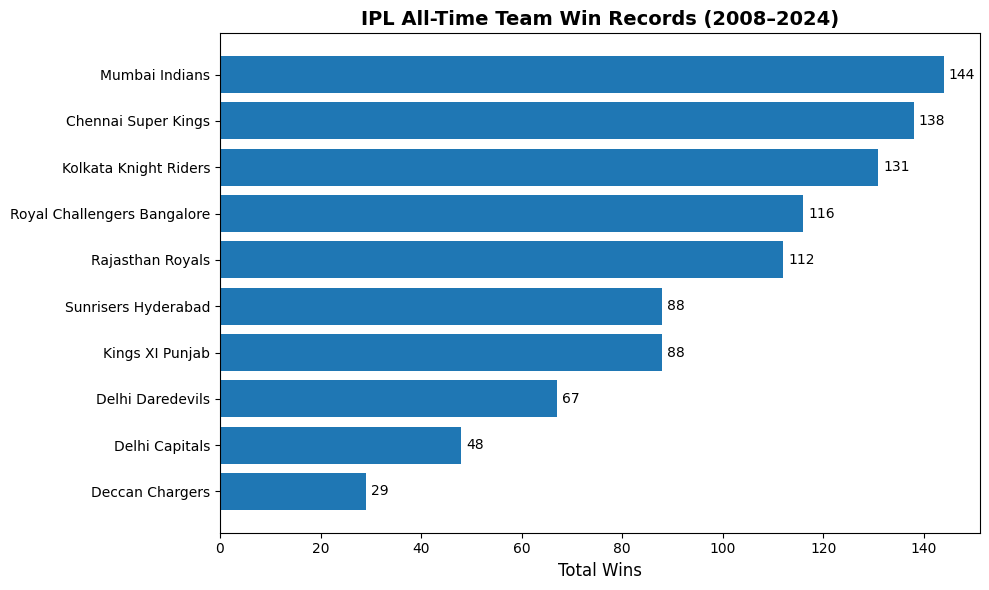

Chart 1 saved!


In [49]:
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(df_team_wins['team'], df_team_wins['total_wins'], color='#1f77b4')
ax.set_xlabel('Total Wins', fontsize=12)
ax.set_title('IPL All-Time Team Win Records (2008–2024)', fontsize=14, fontweight='bold')
ax.invert_yaxis()

# Add value labels on bars
for bar, val in zip(bars, df_team_wins['total_wins']):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../output/chart1_team_wins.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved!")

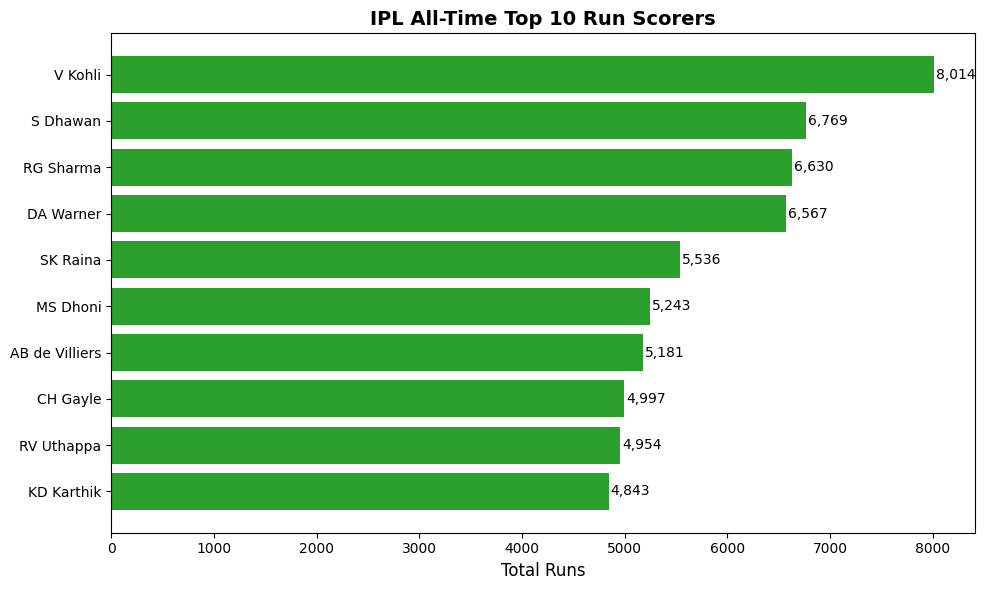

Chart 2 saved!


In [51]:
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(df_top_batters['batter'], df_top_batters['total_runs'], color='#2ca02c')
ax.set_xlabel('Total Runs', fontsize=12)
ax.set_title('IPL All-Time Top 10 Run Scorers', fontsize=14, fontweight='bold')
ax.invert_yaxis()

for bar, val in zip(bars, df_top_batters['total_runs']):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../output/chart2_top_batters.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved!")

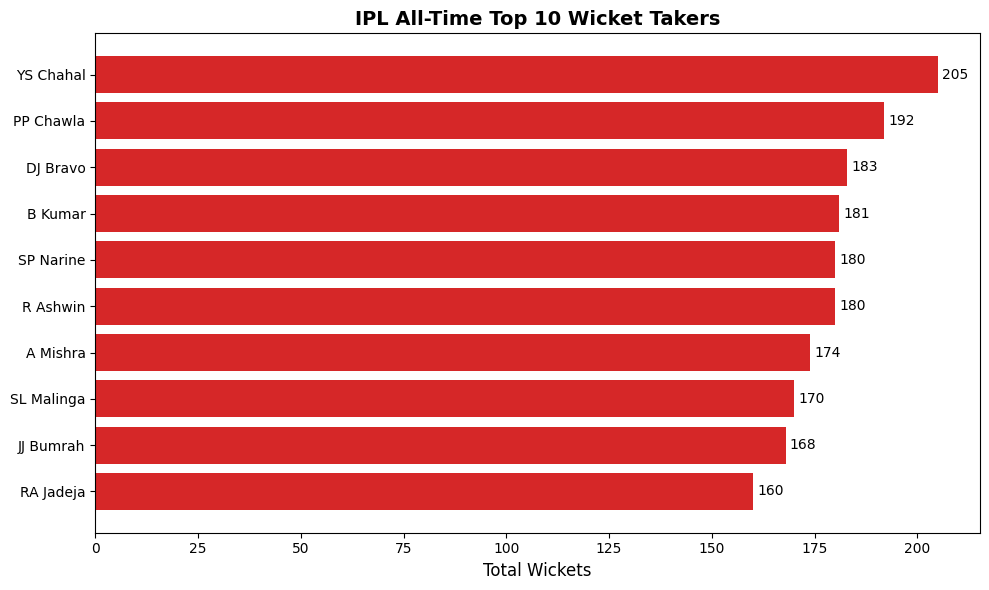

Chart 3 saved!


In [53]:
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(df_top_bowlers['bowler'], df_top_bowlers['total_wickets'], color='#d62728')
ax.set_xlabel('Total Wickets', fontsize=12)
ax.set_title('IPL All-Time Top 10 Wicket Takers', fontsize=14, fontweight='bold')
ax.invert_yaxis()

for bar, val in zip(bars, df_top_bowlers['total_wickets']):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=10)

plt.tight_layout()
plt.savefig('../output/chart3_top_bowlers.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved!")

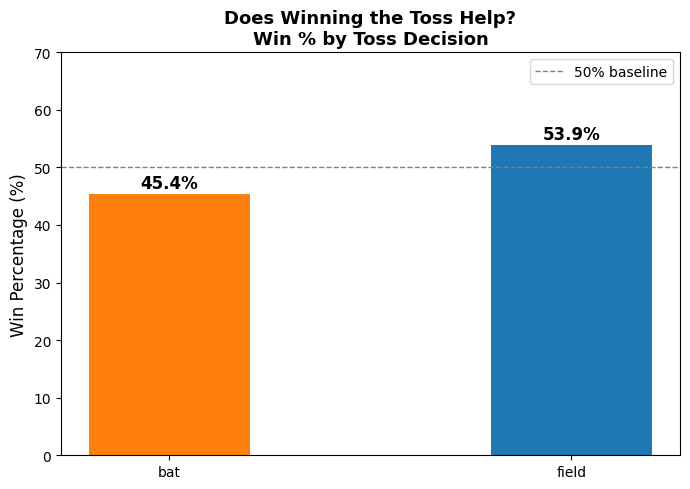

Chart 4 saved!


In [55]:
fig, ax = plt.subplots(figsize=(7, 5))

colors = ['#ff7f0e', '#1f77b4']
bars = ax.bar(df_toss['toss_decision'], df_toss['win_pct'], color=colors, width=0.4)
ax.set_ylabel('Win Percentage (%)', fontsize=12)
ax.set_title('Does Winning the Toss Help?\nWin % by Toss Decision', fontsize=13, fontweight='bold')
ax.set_ylim(0, 70)
ax.axhline(y=50, color='gray', linestyle='--', linewidth=1, label='50% baseline')
ax.legend()

for bar, val in zip(bars, df_toss['win_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val}%', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../output/chart4_toss_impact.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved!")

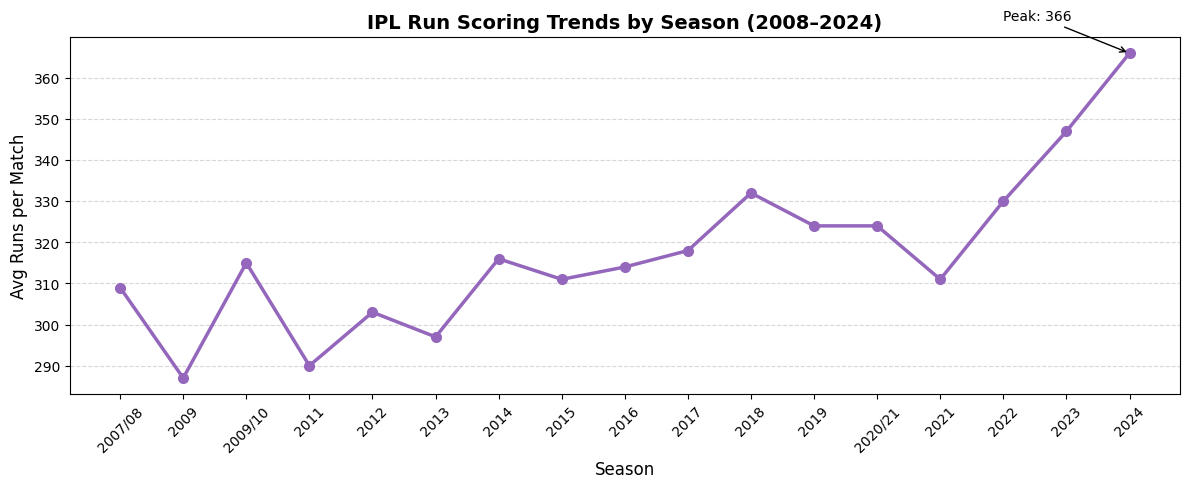

Chart 5 saved!


In [57]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(df_season['season'].astype(str), df_season['avg_runs_per_match'],
        marker='o', color='#9467bd', linewidth=2.5, markersize=7)

ax.set_xlabel('Season', fontsize=12)
ax.set_ylabel('Avg Runs per Match', fontsize=12)
ax.set_title('IPL Run Scoring Trends by Season (2008–2024)', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Highlight min and max
max_idx = df_season['avg_runs_per_match'].idxmax()
min_idx = df_season['avg_runs_per_match'].idxmin()
ax.annotate(f"Peak: {df_season.loc[max_idx, 'avg_runs_per_match']:.0f}",
            xy=(max_idx, df_season.loc[max_idx, 'avg_runs_per_match']),
            xytext=(max_idx - 2, df_season.loc[max_idx, 'avg_runs_per_match'] + 8),
            arrowprops=dict(arrowstyle='->', color='black'), fontsize=10)

plt.tight_layout()
plt.savefig('../output/chart5_season_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 5 saved!")

In [59]:
import os

output_files = os.listdir('../output/')
print("=== Files in output/ folder ===")
for f in sorted(output_files):
    print(f" {f}")

print(f"\nTotal files: {len(output_files)}")
print("\nAll done! Charts + data ready for GitHub.")

=== Files in output/ folder ===
 chart1_team_wins.png
 chart2_top_batters.png
 chart3_top_bowlers.png
 chart4_toss_impact.png
 chart5_season_trends.png
 deliveries_clean.csv
 ipl_database.db
 matches_clean.csv
 season_stats.csv
 team_wins.csv
 top_batters.csv
 top_bowlers.csv
 toss_analysis.csv

Total files: 13

All done! Charts + data ready for GitHub.
